In [ ]:
!pip install PyTelegramBotAPI

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.3/48.3 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 9.6 MB/s eta 0:00:00


In [ ]:
import telebot
from io import BytesIO

In [ ]:
import os
BOT_API='your_BOT_API'
os.environ['HF_TOKEN'] = "your_HF_TOKEN"


In [ ]:
import os
from huggingface_hub import InferenceClient

client = InferenceClient(
    provider="auto",
    api_key=os.environ["HF_TOKEN"],
)


In [ ]:
def ai_image(prompt):
    image = client.text_to_image(
        prompt,
        model="stabilityai/stable-diffusion-xl-base-1.0"
    )
    return image

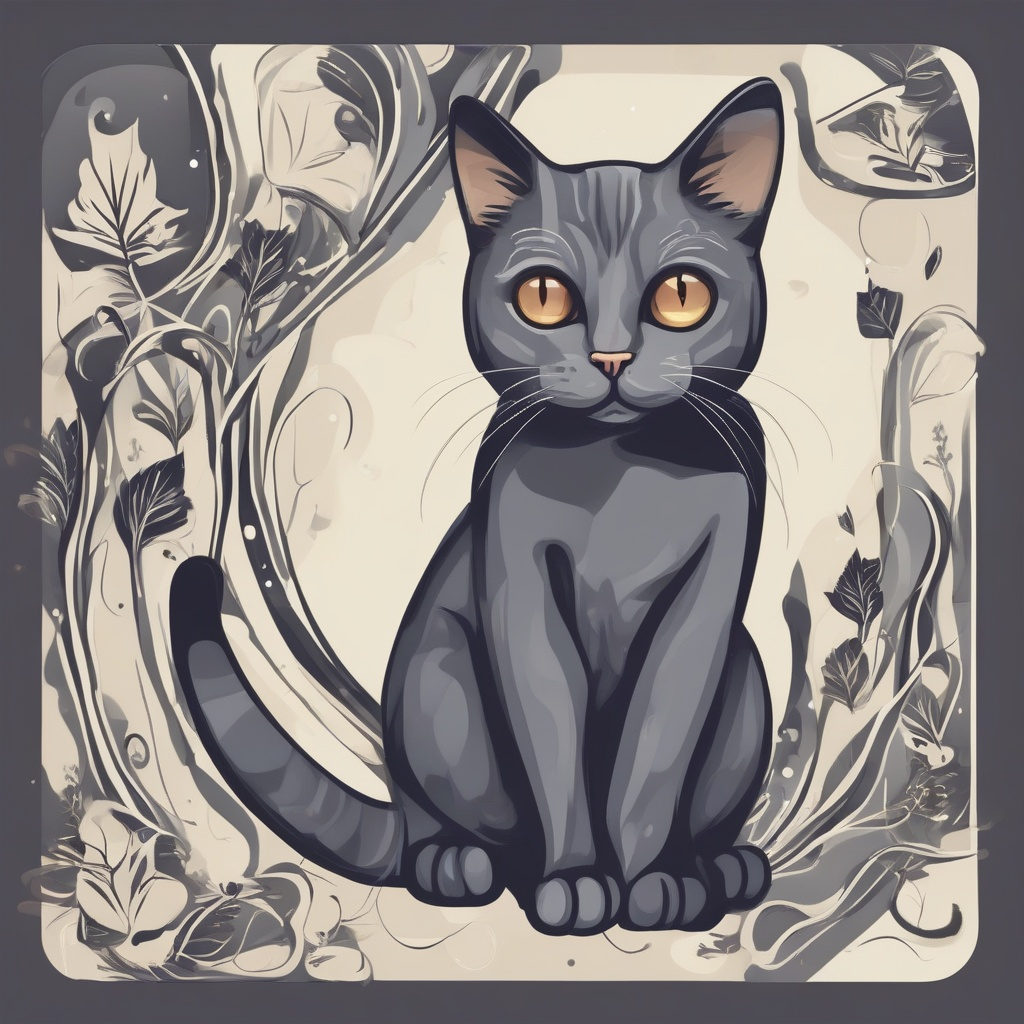

In [ ]:
ai_image('create a image of cat')

In [ ]:
bot=telebot.TeleBot(BOT_API)

In [ ]:
@bot.message_handler(commands=["start"])
def start_message(message):
  bot.reply_to(message,"welcome to bot")

@bot.message_handler(func=lambda message: True)
def message_handler(message):
    prompt = message.text
    bot.reply_to(message,"Generating...")

    try:
        image=ai_image(prompt)

        bio=BytesIO()
        bio.name="image.png"
        image.save(bio,"PNG")
        bio.seek(0)

        bot.send_photo(message.chat.id,bio)

    except Exception:
        bot.reply_to(message,"Something went wrong, try again")

In [ ]:
bot.infinity_polling()
